# 03 Modeling — 학습 · 선택 · 평가
- 과제: 초기 100사이클 데이터로 배터리 수명(cycle_life) **회귀** · 지표 **MAPE**
- 분할: Batch 1 = 학습, Batch 2 = 테스트(1회 평가) · 추가로 Batch 3 검증
- 설계 원칙(1일차): **실제 배터리 수명보다 길게 예측하지 않기** — 늦은 교체는 공급 중단 · 위약금으로 이어진다
- 파이프라인 코드는 `src/train.py`에 있고, 이 노트북은 그 함수를 불러 결과를 보여 주고 해석한다

In [1]:
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import train as T
from config import CANDIDATES, CORE, FIG_DIR, LATE_COST_GRID, RESULTS_DIR, TARGET_MAPE
from features import energy_value_curve
from preprocess import load_cells

plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.dpi': 110})
pd.set_option('display.width', 200, 'display.max_columns', 30)
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. 데이터 분할 — 같은 충전 방식은 같은 쪽에
- Batch 1의 36셀은 충전 방식 20개로 실험됐고, 대부분 방식마다 2셀(짝 셀)이다
- 짝 셀이 학습과 검증에 갈리면 검증 셀의 "쌍둥이"를 이미 본 셈이라 성능이 부풀려진다 → **방식 단위로 분할**
- 검증: 방식 20개를 평균 수명 순으로 세우고 4개마다 1개(index % 4 == 1) → 수명 범위 전체에서 고르게 5개 방식 · 8셀
- 학습 28셀 안의 교차검증도 `GroupKFold(groups=policy)`로 같은 규칙을 지킨다

In [2]:
b1, b2, b3 = T.load_data()
train, valid = T.split_holdout(b1)
split = pd.DataFrame({'역할': ['학습', '검증 (Hold-out)', '테스트', '추가 검증'],
                      'Batch': ['B1', 'B1', 'B2', 'B3'],
                      '셀 수': [len(train), len(valid), len(b2), len(b3)],
                      '충전 방식 수': [train.policy.nunique(), valid.policy.nunique(), b2.policy.nunique(), b3.policy.nunique()],
                      '수명 범위': [f'{d.cycle_life.min():.0f} ~ {d.cycle_life.max():.0f}' for d in (train, valid, b2, b3)]})
print('학습 · 검증에 겹치는 충전 방식:', set(train.policy) & set(valid.policy) or '없음')
split

학습 · 검증에 겹치는 충전 방식: 없음


,역할,Batch,셀 수,충전 방식 수,수명 범위
0,학습,B1,28,15,534 ~ 1074
1,검증 (Hold-out),B1,8,5,599 ~ 1014
2,테스트,B2,39,12,392 ~ 1186
3,추가 검증,B3,44,8,541 ~ 1935


## 2. 후보 모델 — 1일차 전략 그대로
| 후보 | 1일차 근거 |
|---|---|
| 선형회귀 (ΔQ 분산 1개) | 기준선. 테스트의 77%가 학습 범위 밖 → 직선 연장이 가능한 선형 계열 |
| 선형회귀 (ΔQ 분산 + 후보 조합 15가지) | 후보 피처(왜도 · 용량 기울기 · 저항 · 온도)는 "교차검증으로 결정" |
| ElasticNet (alpha 4 × l1 비율 3) | ΔQ 계열 신호끼리 중복 + 학습 36셀 → 규제 |
| 분위수 회귀 (하위 10 · 20%) | 실제보다 길게 예측하는 쪽에 벌점 (pinball 손실) |
| 랜덤포레스트 · LightGBM | 비교용 — 학습 범위 밖 예측 한계 확인 |

전처리(결측 대체 · 표준화)는 Pipeline 안에 있어 교차검증 fold마다 학습 부분에만 맞춘다.

In [3]:
cand = T.candidates()
P = T.stage_predictions(cand, train, valid, b1, b2, b3)
acc = pd.DataFrame(
    [{'후보': n, '계열': T.family(n), 'Train CV MAPE': T.mape(train.cycle_life, P[n]['train_cv']),
      'Valid MAPE': T.mape(valid.cycle_life, P[n]['valid'])} for n, _, _ in cand]).sort_values('Train CV MAPE')
print(f'후보 {len(cand)}개 — 계열별 최선 (학습 교차검증 MAPE 기준, 테스트 미사용)')
acc.groupby('계열', sort=False).head(1).round(2).reset_index(drop=True)

후보 34개 — 계열별 최선 (학습 교차검증 MAPE 기준, 테스트 미사용)


,후보,계열,Train CV MAPE,Valid MAPE
0,선형회귀 (ΔQ 분산),선형회귀,8.22,10.52
1,"ElasticNet (alpha=0.01, l1=0.5)",ElasticNet,8.60,9.70
2,"분위수 회귀 (하위 20%, ΔQ 분산)",분위수 회귀,10.16,7.65
3,랜덤포레스트 (비교용),랜덤포레스트,10.94,11.45
4,LightGBM (비교용),LightGBM,14.36,16.08


## 3. 성능 리포팅 (과제 포맷) — 모델 자체의 정확도
- 여유 배율을 곱하기 **전** 예측의 MAPE. 원논문(9.1%)과 비교하는 값이다
- MAPE는 낮을수록 좋으므로 Gap은 **뒤 단계 − 앞 단계**로 계산해 (+)면 뒤 단계에서 나빠졌다는 뜻이다

In [4]:
report = [T.BASELINE] + [n for n in acc.groupby('계열', sort=False).head(1).후보 if n != T.BASELINE]
perf = pd.concat([T.performance_table(n, P, train, valid, b2, b3) for n in report], axis=1)
perf.round(2)

,선형회귀 (ΔQ 분산),"ElasticNet (alpha=0.01, l1=0.5)","분위수 회귀 (하위 20%, ΔQ 분산)",랜덤포레스트 (비교용),LightGBM (비교용)
Train (B1 CV),8.22,8.60,10.16,10.94,14.36
Valid (B1 Hold-out),10.52,9.70,7.65,11.45,16.08
Test (B2),28.56,30.66,21.54,30.59,29.06
"Test (B3, 추가)",12.81,12.18,13.53,16.91,17.12
Gap (Train−Valid),2.31,1.10,-2.50,0.51,1.73
Gap (Valid−Test),18.04,20.96,13.89,19.14,12.97
Gap (Target−Test),19.46,21.56,12.44,21.49,19.96
"Gap (B2−B3, 추가)",-15.75,-18.48,-8.01,-13.68,-11.94


**해석**
- **Gap (Train−Valid)** 은 −2.5 ~ +2.4%p로 작다 → Batch 1 안에서는 과적합이 크지 않다
- **Gap (Valid−Test)** 는 모든 모델에서 +13 ~ +21%p → **배치가 바뀌면 성능이 크게 떨어진다** (7절에서 원인 분석)
- **Gap (Target−Test)**: 기준선 B2 MAPE 28.6%는 원논문 9.1%보다 19.5%p 높다
- B3에서는 MAPE 12 ~ 17%로 B2보다 훨씬 낫다 → 문제는 "새 배치" 일반이 아니라 **B2 특유의 무언가**

## 4. 손실 기준 — 일찍 교체하면 무엇을 잃나
셀 하나의 손실 (단위: 배터리 교체비)
- **일찍 교체**: 남긴 수명 동안 더 내줄 수 있었던 방전량 비율 v(남긴 수명 비율)
- **늦게 교체**: 1건당 R (공급 중단 · 위약금 · 긴급 교체 할증) — **회사 값이라 모르므로 R을 바꿔 가며 모두 실험**

v는 가정하지 않고 Batch 1 실제 용량 곡선으로 측정했다. 용량은 끝으로 갈수록 빨리 줄지만(무릎점 이후 약 10배)
1.07 → 0.88Ah 범위 안이라 마지막 사이클도 처음의 80% 이상을 방전한다 → 남긴 수명 20%면 방전량은 18.3%를 버린다.

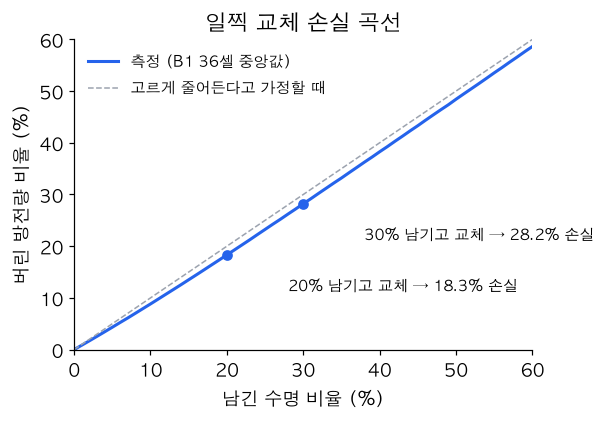

In [5]:
curve = energy_value_curve(load_cells(['b1']), dict(zip(b1.cell_id, b1.cycle_life)))
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.plot(curve[0] * 100, curve[1] * 100, color='#2563eb', lw=2, label='측정 (B1 36셀 중앙값)')
ax.plot([0, 100], [0, 100], color='#9ca3af', ls='--', lw=1, label='고르게 줄어든다고 가정할 때')
for f in [0.2, 0.3]:
    v = np.interp(f, *curve); ax.scatter(f * 100, v * 100, color='#2563eb', zorder=3)
    ax.annotate(f'{f:.0%} 남기고 교체 → {v:.1%} 손실', (f * 100, v * 100), (f * 100 + 8, v * 100 - 7), fontsize=10)
ax.set_xlim(0, 60); ax.set_ylim(0, 60); ax.set_xlabel('남긴 수명 비율 (%)'); ax.set_ylabel('버린 방전량 비율 (%)')
ax.set_title('일찍 교체 손실 곡선'); ax.legend(frameon=False, fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm1_energy_value_curve.png', dpi=200, bbox_inches='tight'); plt.show()

## 5. R별 선택 — 회사 손실 비율을 모르므로 전부 보여 준다
R마다 **학습 데이터(28셀 교차검증)만으로** 손실이 최소인 여유 배율과 모델을 고르고, 검증 · B2 · B3에는 그대로 적용한다.
(최종 모델은 B1 36셀로 다시 학습하고, 여유 배율도 36셀 교차검증으로 다시 구한다)

In [6]:
sweep = T.cost_sweep(P, train, valid, b1, b2, b3, curve)
show = ['R', '선택 모델', '여유 배율 (B1 36셀)', '학습 CV 늦은 교체', '검증 늦은 교체', 'B2 늦은 교체', 'B3 늦은 교체', 'B3 평균 일찍(%)']
sweep[show].round(2)

,R,선택 모델,여유 배율 (B1 36셀),학습 CV 늦은 교체,검증 늦은 교체,B2 늦은 교체,B3 늦은 교체,B3 평균 일찍(%)
0,0.1,선형회귀 (ΔQ 분산 + qd_slope_2_100 + ir_min + tavg_m...,1.10,15/28,8/8,39/39,31/44,3.50
1,0.2,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.96,5/28,4/8,37/39,25/44,4.80
2,0.3,선형회귀 (ΔQ 분산 + dq_skew + qd_slope_2_100),0.88,5/28,4/8,32/39,15/44,8.77
3,0.4,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
4,0.5,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
5,0.6,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
6,0.7,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
7,0.8,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
8,0.9,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19
9,1.0,선형회귀 (ΔQ 분산),0.90,2/28,2/8,33/39,12/44,11.19


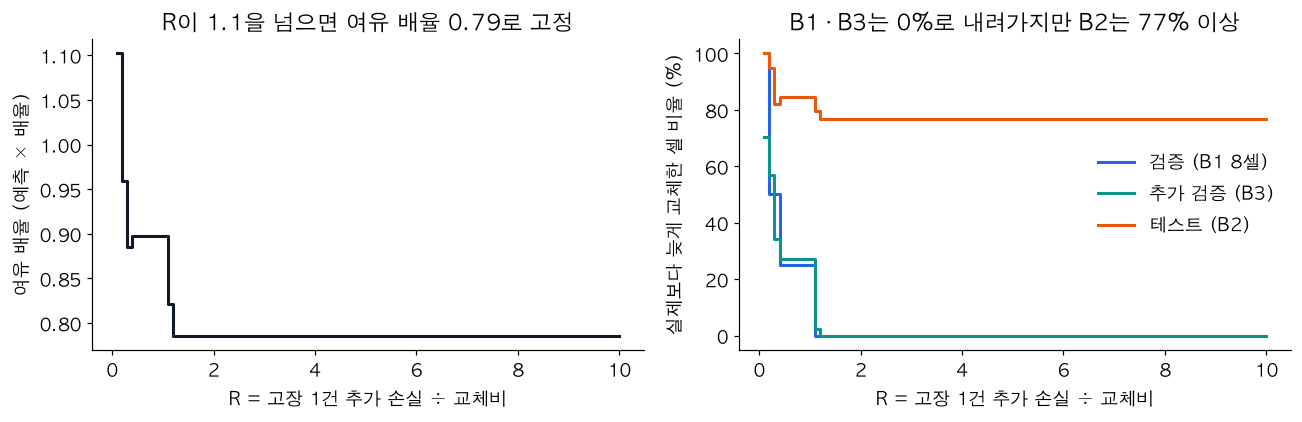

In [7]:
fin = sweep[np.isfinite(sweep.R)]
late = lambda s: s.str.split('/').str[0].astype(int) / s.str.split('/').str[1].astype(int) * 100
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].step(fin.R, fin['여유 배율 (B1 36셀)'], where='post', color='#111827', lw=2)
ax[0].set_xlabel('R = 고장 1건 추가 손실 ÷ 교체비'); ax[0].set_ylabel('여유 배율 (예측 × 배율)')
ax[0].set_title('R이 1.1을 넘으면 여유 배율 0.79로 고정')
for col, lab, c in [('검증 늦은 교체', '검증 (B1 8셀)', '#2563eb'), ('B3 늦은 교체', '추가 검증 (B3)', '#0d9488'), ('B2 늦은 교체', '테스트 (B2)', '#ea580c')]:
    ax[1].step(fin.R, late(fin[col]), where='post', lw=2, color=c, label=lab)
ax[1].set_xlabel('R = 고장 1건 추가 손실 ÷ 교체비'); ax[1].set_ylabel('실제보다 늦게 교체한 셀 비율 (%)')
ax[1].set_title('B1 · B3는 0%로 내려가지만 B2는 77% 이상'); ax[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm2_cost_sensitivity.png', dpi=200, bbox_inches='tight'); plt.show()

In [8]:
FINAL = sweep.loc[sweep.R == float('inf'), '선택 모델'].iloc[0]          # R ≥ 1.1 구간에서 고른 모델
print('R ≥ 1.1 구간의 선택 모델:', FINAL, '/ R 0.4 ~ 1.0 구간:', T.BASELINE)
final_perf = pd.concat([T.performance_table(n, P, train, valid, b2, b3) for n in [FINAL, T.BASELINE]], axis=1)
from sklearn.base import clone
coef = {n: clone(e).fit(b1[f], b1[T.TARGET])[-1].coef_ for n, f, e in cand if n in (FINAL, T.BASELINE)}
print('ΔQ 분산 계수 (표준화 단위):', {n: np.round(c[0], 4) for n, c in coef.items()}, '| ElasticNet의 나머지 후보 계수:', np.round(coef[FINAL][1:], 4))
final_perf.round(2)

R ≥ 1.1 구간의 선택 모델: ElasticNet (alpha=0.03, l1=0.9) / R 0.4 ~ 1.0 구간: 선형회귀 (ΔQ 분산)
ΔQ 분산 계수 (표준화 단위): {'선형회귀 (ΔQ 분산)': np.float64(-0.0682), 'ElasticNet (alpha=0.03, l1=0.9)': np.float64(-0.0411)} | ElasticNet의 나머지 후보 계수: [-0.  0.  0. -0.]


,"ElasticNet (alpha=0.03, l1=0.9)",선형회귀 (ΔQ 분산)
Train (B1 CV),10.61,8.22
Valid (B1 Hold-out),9.03,10.52
Test (B2),38.81,28.56
"Test (B3, 추가)",14.06,12.81
Gap (Train−Valid),-1.58,2.31
Gap (Valid−Test),29.78,18.04
Gap (Target−Test),29.71,19.46
"Gap (B2−B3, 추가)",-24.75,-15.75


**해석**
- 답은 세 구간으로 나뉜다: R ≤ 0.3이면 거의 보정하지 않고, 0.4 ~ 1.0이면 여유 0.90(학습 늦은 교체 2/28), **R ≥ 1.1이면 여유 0.79 ~ 0.82로 늦은 교체 0건**
- 고른 모델은 사실상 모두 **ΔQ 분산 1개짜리 직선**이다. R ≥ 1.1에서 고른 ElasticNet도 후보 4개의 계수를 모두 0으로 만들었다 → 1일차에 "확정"한 피처 하나로 충분했다
- 다만 그 ElasticNet은 ΔQ 기울기를 기준선의 약 60%로 줄인 **완만한 직선**이다. 학습 범위 안에서는 여유 손실이 가장 작았지만, 짧은 수명 쪽으로 덜 내려가 짧은 셀이 많은 B2에서 MAPE 38.8%로 가장 나빴다 (1일차의 "수명 미확정 셀을 넣으면 기울기가 완만해져 B2가 나빠진다"와 같은 현상)
- R ≥ 1.2이면 검증 0/8, B3 0/44 — 같은 배치 · 다른 배치(B3) 모두에서 늦은 교체를 막았다. 대가는 B3 기준 평균 28% 일찍 경고
- **B2는 어떤 R에서도 30/39 이상 늦게 교체한다** → 손실 설정의 문제가 아니라 데이터의 문제 (7절)

## 6. 예측 vs 실제 — R ≥ 1.1 구간의 선택 모델 + 여유 배율
검증 셀에는 학습 28셀로 구한 배율, B2 · B3에는 B1 36셀로 구한 배율을 곱한다 (5절 표와 같은 규칙)

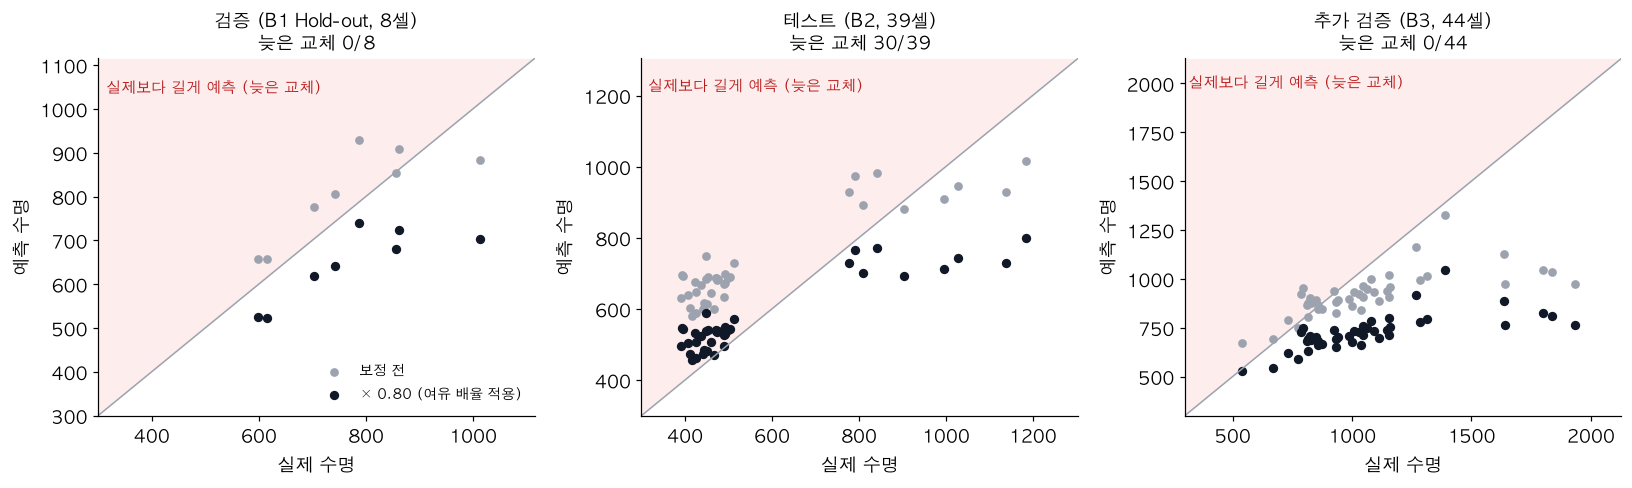

In [9]:
m_tr = T.best_margin(train.cycle_life, P[FINAL]['train_cv'], float('inf'), curve)[0]
m_b1 = T.best_margin(b1.cycle_life, P[FINAL]['b1_cv'], float('inf'), curve)[0]
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharey=False)
for a, (name, y, p, m_hi) in zip(ax, [('검증 (B1 Hold-out, 8셀)', valid.cycle_life, P[FINAL]['valid'], m_tr),
                                       ('테스트 (B2, 39셀)', b2.cycle_life, P[FINAL]['b2'], m_b1),
                                       ('추가 검증 (B3, 44셀)', b3.cycle_life, P[FINAL]['b3'], m_b1)]):
    lo, hi = 300, max(y.max(), p.max()) * 1.1
    a.fill_between([lo, hi], [lo, hi], [hi, hi], color='#fee2e2', alpha=0.6, lw=0)
    a.text(lo * 1.05, hi * 0.93, '실제보다 길게 예측 (늦은 교체)', color='#b91c1c', fontsize=10)
    a.plot([lo, hi], [lo, hi], color='#9ca3af', lw=1)
    a.scatter(y, p, s=22, color='#9ca3af', label='보정 전')
    a.scatter(y, p * m_hi, s=26, color='#111827', label=f'× {m_hi:.2f} (여유 배율 적용)')
    a.set_xlim(lo, hi); a.set_ylim(lo, hi); a.set_xlabel('실제 수명'); a.set_ylabel('예측 수명')
    a.set_title(f'{name}\n늦은 교체 {(p * m_hi > y).sum()}/{len(y)}', fontsize=12)
ax[0].legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout(); plt.savefig(FIG_DIR / 'm3_pred_vs_actual.png', dpi=200, bbox_inches='tight'); plt.show()

## 7. 오류 분석 — B2에서 크게 틀린 셀의 공통점

In [10]:
feat = pd.read_csv('../data/processed/features.csv')
e2 = b2[['cell_id', 'policy', 'cycle_life', 'dq_var_log', 'c1', 'c2']].assign(pred=P[T.BASELINE]['b2'])
e2['오차(%)'] = (e2.pred - e2.cycle_life) / e2.cycle_life * 100
e2['newstructure'] = e2.policy.str.contains('newstructure')
print('가장 크게 틀린 8셀 (기준선, 보정 전)')
e2.nlargest(8, '오차(%)')[['cell_id', 'policy', 'cycle_life', 'pred', '오차(%)', 'newstructure']].round(1)

가장 크게 틀린 8셀 (기준선, 보정 전)


,cell_id,policy,cycle_life,pred,오차(%),newstructure
6,b2c6,3.6C(9%)-5C,393.0,648.2,64.9,False
18,b2c18,5.2C(50%)-4.25C,449.0,731.8,63.0,False
15,b2c15,3.6C(9%)-5C,396.0,642.1,62.1,False
2,b2c2,5.2C(50%)-4.25C,424.0,618.0,45.7,False
9,b2c9,5.6C(26%)-4.5C-newstructure,791.0,1131.8,43.1,True
27,b2c29,5.2C(58%)-4C,452.0,638.6,41.3,False
19,b2c19,6C(60%)-3C,392.0,550.7,40.5,False
11,b2c11,5.2C(50%)-4.25C,449.0,628.7,40.0,False


In [11]:
g = e2.groupby('newstructure').agg(셀=('cell_id', 'size'), 수명_최소=('cycle_life', 'min'), 수명_최대=('cycle_life', 'max'),
                                   수명_중앙값=('cycle_life', 'median'), 오차_중앙값=('오차(%)', 'median'))
print('충전 속도와 오차의 상관: C1 r = %.2f, C2 r = %.2f' % (e2[['오차(%)', 'c1']].corr().iloc[0, 1], e2[['오차(%)', 'c2']].corr().iloc[0, 1]))
same = e2[e2.policy.str.replace('-newstructure', '').isin(e2[e2.newstructure].policy.str.replace('-newstructure', ''))]
print('\n같은 충전 방식, 구조 표기만 다른 셀')
print(same.assign(방식=same.policy.str.replace('-newstructure', '')).groupby(['방식', 'newstructure']).cycle_life.agg(['count', 'median']).to_string())
g.round(1)

충전 속도와 오차의 상관: C1 r = -0.15, C2 r = -0.17

같은 충전 방식, 구조 표기만 다른 셀
                             count  median
방식             newstructure               
4.8C(80%)-4.8C False             5   492.0
               True              3   809.0
5.2C(58%)-4C   False             4   483.0
               True              3   904.0
5.6C(26%)-4.5C False             6   446.0
               True              3   997.0


,셀,수명_최소,수명_최대,수명_중앙값,오차_중앙값
newstructure,,,,,
False,30,392.0,514.0,451.0,32.2
True,9,777.0,1186.0,904.0,6.1


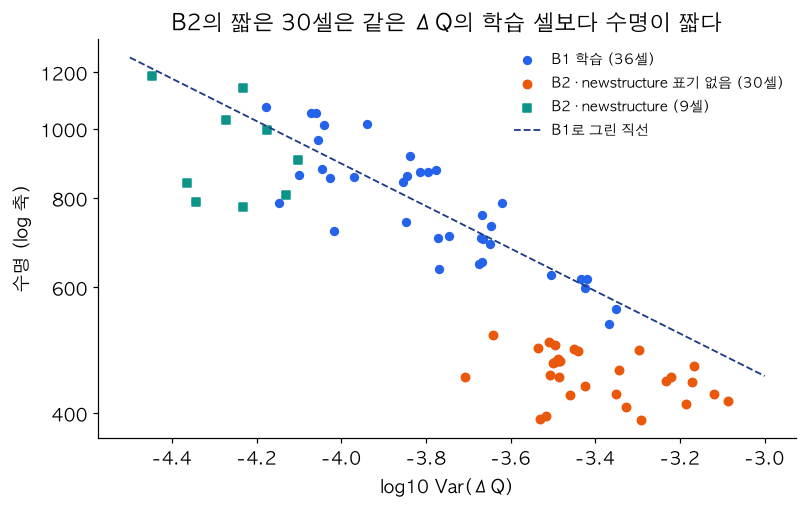

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))
fit = np.polyfit(b1.dq_var_log, np.log10(b1.cycle_life), 1)
ax.scatter(b1.dq_var_log, b1.cycle_life, s=26, color='#2563eb', label='B1 학습 (36셀)')
for flag, c, lab in [(False, '#ea580c', 'B2 · newstructure 표기 없음 (30셀)'), (True, '#0d9488', 'B2 · newstructure (9셀)')]:
    d = e2[e2.newstructure == flag]; ax.scatter(d.dq_var_log, d.cycle_life, s=30, color=c, label=lab, marker='s' if flag else 'o')
xs = np.linspace(-4.5, -3.0, 50); ax.plot(xs, 10 ** np.polyval(fit, xs), color='#1e3a8a', ls='--', lw=1.2, label='B1로 그린 직선')
ax.set_yscale('log'); ax.set_yticks([400, 600, 800, 1000, 1200]); ax.set_yticklabels(['400', '600', '800', '1000', '1200']); ax.minorticks_off()
ax.set_xlabel('log10 Var(ΔQ)'); ax.set_ylabel('수명 (log 축)')
ax.set_title('B2의 짧은 30셀은 같은 ΔQ의 학습 셀보다 수명이 짧다'); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.savefig(FIG_DIR / 'm4_error_b2_structure.png', dpi=200, bbox_inches='tight'); plt.show()

**오류 분석 결과**
- **공통점**: 크게 틀린 8셀 중 7셀이 충전 방식 이름에 `newstructure` 표기가 **없는** 셀이다. 표기 없는 30셀은 수명 392 ~ 514로 전부 학습 최솟값(534) 아래이고 기준선 오차 중앙값이 32%다. 표기가 있는 9셀은 777 ~ 1,186이고 오차 중앙값이 6%다
- **충전 조건 탓이 아니다**: 같은 충전 방식(예: 4.8C(80%)-4.8C)인데 표기 유무에 따라 수명이 약 2배 차이 나고, 오차와 충전 속도(C1 · C2)의 상관은 |r| < 0.2다
- **곡선 변화와 수명의 관계가 다르다**: 짧은 30셀 중 19셀은 ΔQ 분산이 학습 셀과 같은 범위에 있다. 그런데 같은 ΔQ의 학습 셀이 약 600 사이클을 사는 동안 이 셀들은 약 450에서 끝났다 → "같은 곡선 변화 = 같은 수명"이라는 학습 배치의 관계가 이 30셀에서는 성립하지 않는다
- **원인 가설**: 충전 조건 밖의 실험 · 셀 조건(표기가 가리키는 실험 구조 차이, 생산 로트 등)이 수명을 줄였지만 초기 100사이클의 ΔQ에는 드러나지 않았다. 원인을 확정하려면 실험 기록(메타데이터)이 필요하다
- **개선 방향**: (1) 새 배치 · 로트가 들어오면 일부 셀을 수명 끝까지 돌려 여유 배율을 다시 맞춘다 (2) 실험 · 생산 메타데이터를 피처로 기록한다 (3) 학습에 여러 배치를 섞어 배치 차이를 모델이 보게 한다
- 테스트 결과를 본 뒤이므로 위 개선은 **모델에 반영하지 않았다** (테스트 기반 수정 = 누수)